In [1]:
# First, let's import everything we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load the dataset
print("Loading California Housing Dataset...")
housing = fetch_california_housing(as_frame=True)

Loading California Housing Dataset...


In [4]:
# Create a DataFrame
df = housing.frame
print("Data loaded sucessfully!")
print("shape: {df.shape}")
print(f'\n First 5 rows:')
print(df.head())

Data loaded sucessfully!
shape: {df.shape}

 First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [5]:
# Dataset description
print("\n" + "="*50)
print("DATASET DESCRIPTION")
print("="*50)
print(housing.DESCR)


DATASET DESCRIPTION
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

Thi

PART 2: EXPLORATORY DATA ANALYSIS (EDA)

In [6]:
# Basic information
print("\n=== BASIC INFORMATION ===")
print(df.info())
print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())


=== BASIC INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

=== STATISTICAL SUMMARY ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.

In [7]:
# checking for missing values 
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== MISSING VALUES ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [8]:
# checking for duplicates
print(f"\nDuplicated rows : {df.duplicated().sum()}")


Duplicated rows : 0


PART 3: CORRELATION ANALYSIS

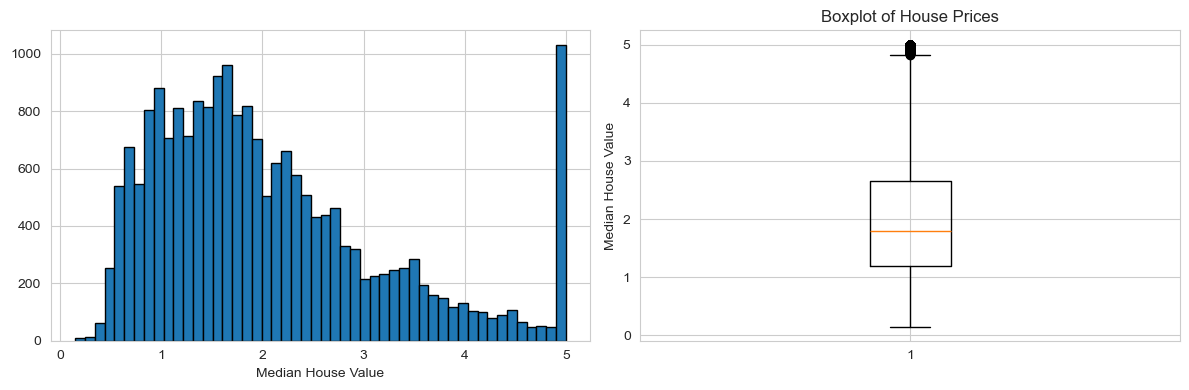

In [9]:
# Target variable distribution
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.hist(df['MedHouseVal'], bins = 50, edgecolor = 'black')
plt.xlabel('Median House Value')
plt.subplot(1,2,2)
plt.boxplot(df['MedHouseVal'])
plt.ylabel('Median House Value')
plt.title('Boxplot of House Prices')
plt.tight_layout()
plt.show()

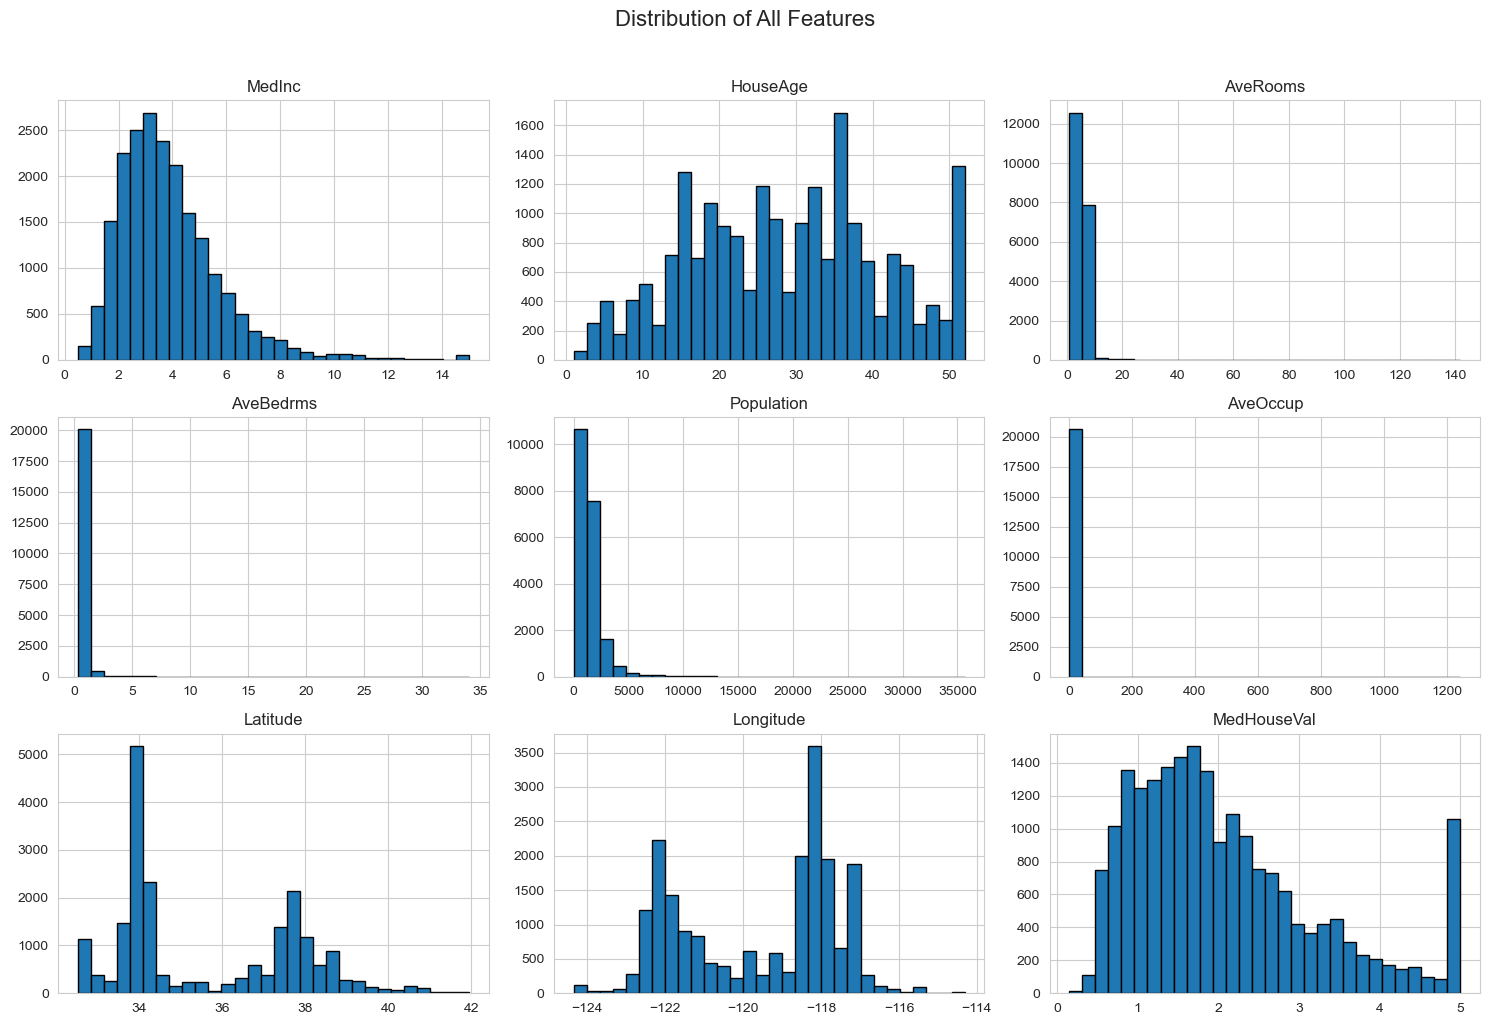

In [10]:
# Distribution of all features
df.hist(bins=30, figsize = (15,10), edgecolor = 'black')
plt.suptitle('Distribution of All Features', y = 1.02, fontsize = 16)
plt.tight_layout()
plt.show()

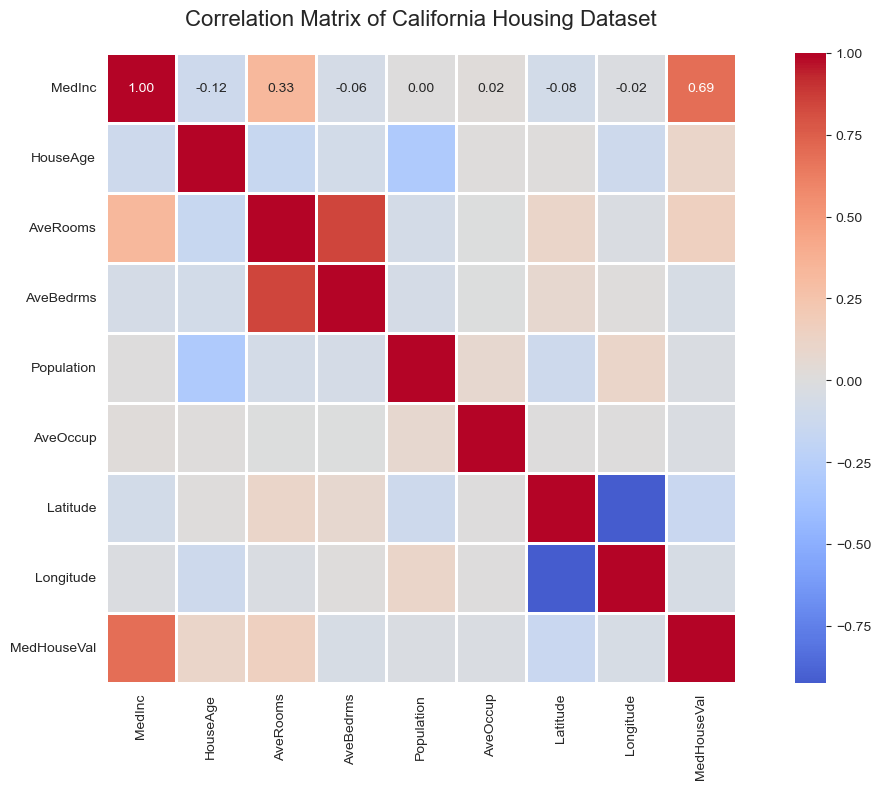


=== CORRELATION WITH TARGET VARIABLE ===
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [11]:
plt.figure(figsize=(12,8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', center = 0, fmt='.2f', square=True, linewidth = 1 )
plt.title('Correlation Matrix of California Housing Dataset', fontsize = 16, pad = 20)
plt.tight_layout()
plt.show()
# Correlation matrix with target variable 
target_corr = correlation_matrix['MedHouseVal'].sort_values(ascending=False)
print("\n=== CORRELATION WITH TARGET VARIABLE ===")
print(target_corr)

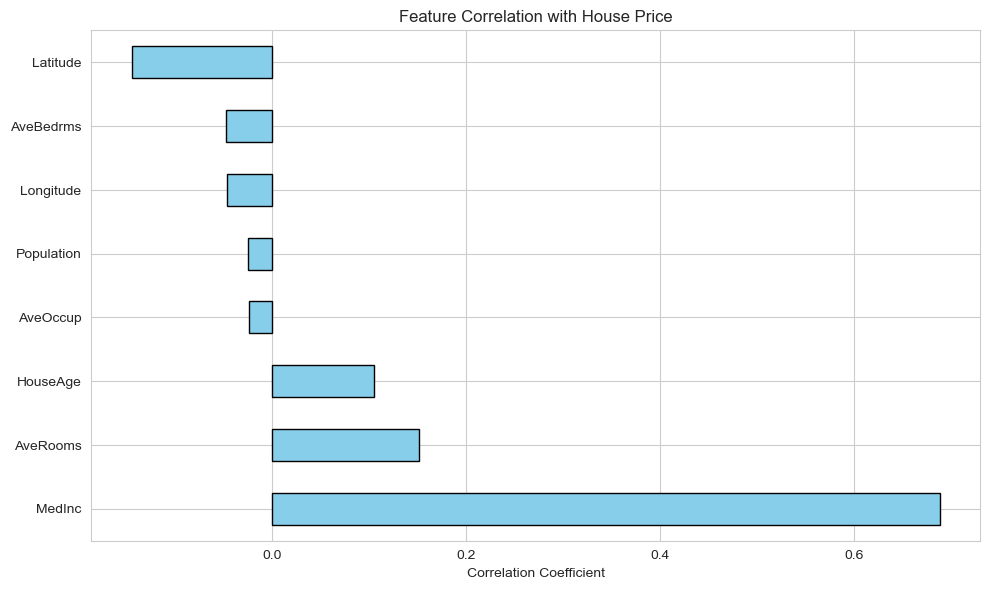

In [12]:
# Visualize top correlations
plt.figure(figsize = (10,6))
target_corr[1:].plot(kind = 'barh', color = 'skyblue', edgecolor = 'black')
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlation with House Price')
plt.tight_layout()
plt.show()

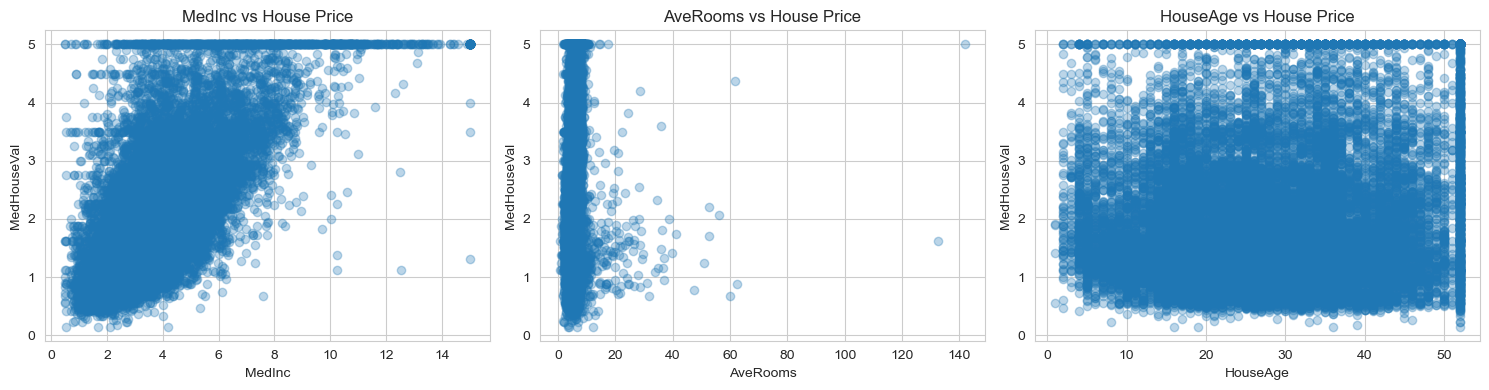

In [13]:
# Scatter plots for top correlated features
top_features = target_corr[1:4].index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['MedHouseVal'], alpha=0.3)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('MedHouseVal')
    axes[idx].set_title(f'{feature} vs House Price')
plt.tight_layout()
plt.show()

PART 4: OUTLIER DETECTION AND HANDLING

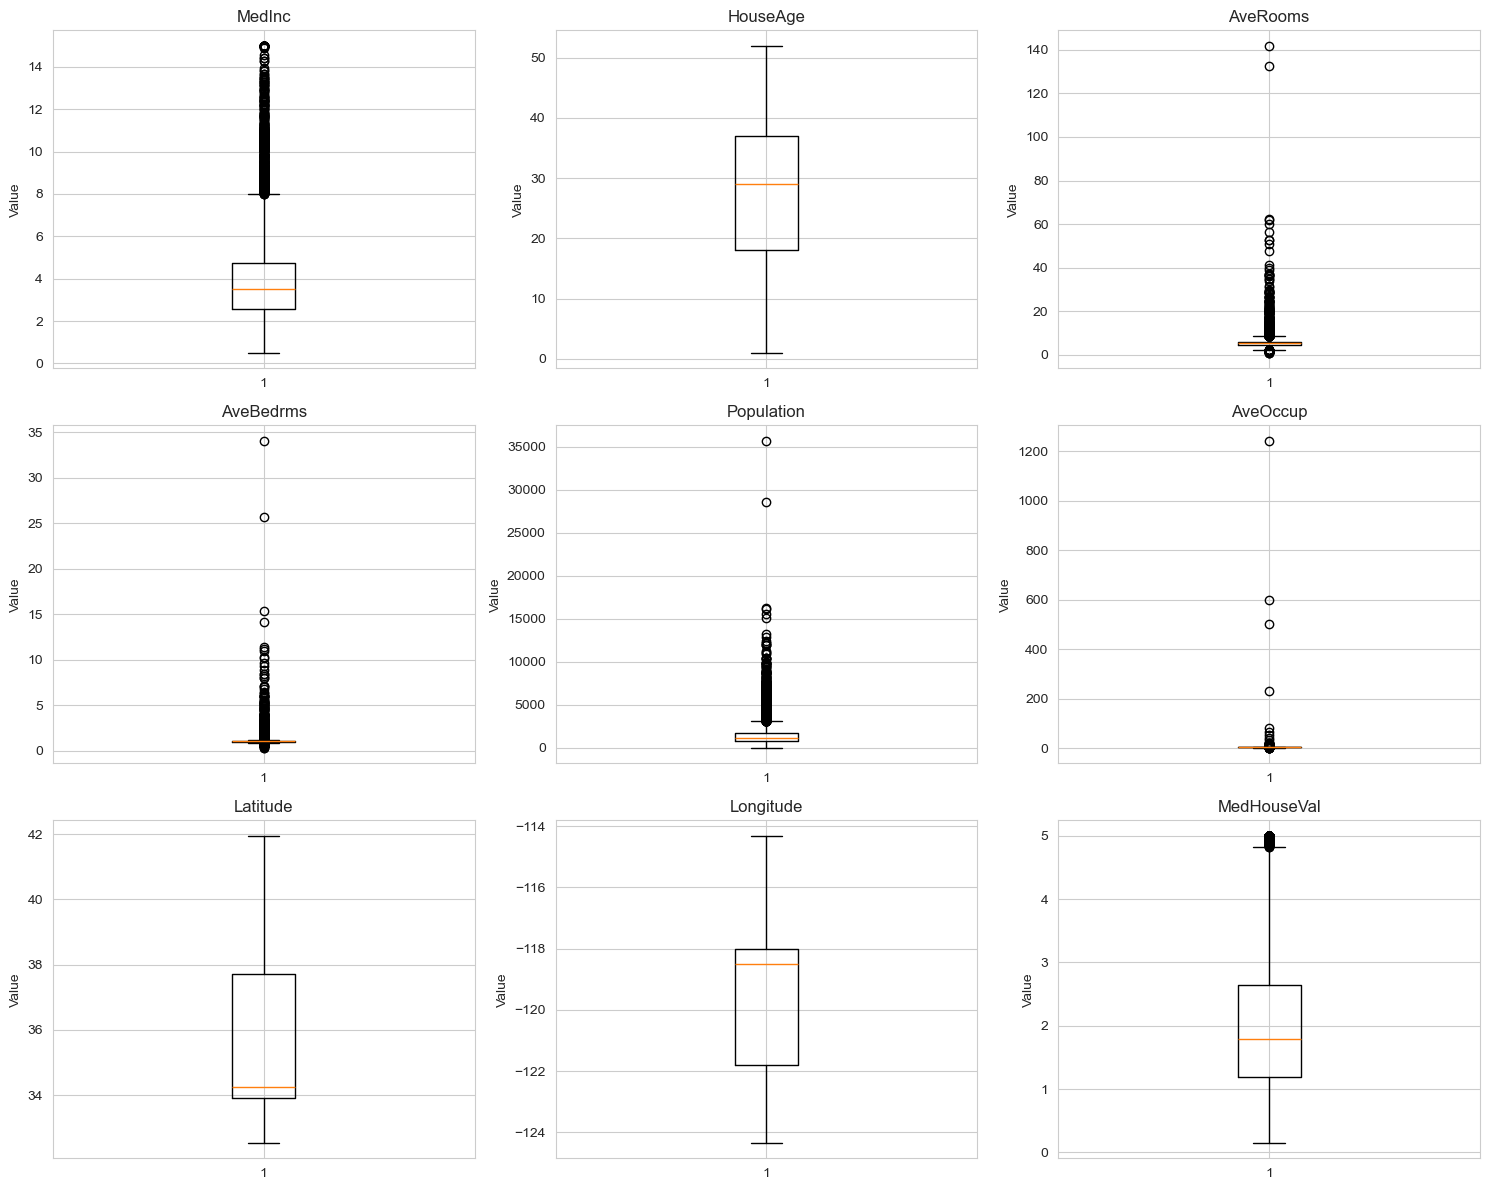


=== OUTLIER DETECTION (IQR Method) ===
MedInc: 681 outliers (3.30%)
HouseAge: 0 outliers (0.00%)
AveRooms: 511 outliers (2.48%)
AveBedrms: 1424 outliers (6.90%)
Population: 1196 outliers (5.79%)
AveOccup: 711 outliers (3.44%)
Latitude: 0 outliers (0.00%)
Longitude: 0 outliers (0.00%)
MedHouseVal: 1071 outliers (5.19%)


In [14]:
# Boxplots for all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')
    
plt.tight_layout()
plt.show()

# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

print("\n=== OUTLIER DETECTION (IQR Method) ===")
for col in df.columns:
    n_outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")

In [15]:
# Keep a backup copy, then continue editing df
df_backup = df.copy()

# Remove outliers using IQR (feature columns only)
outlier_cols = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
rows_before = len(df)

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df = df.reset_index(drop=True)
rows_after = len(df)

print("=== OUTLIER HANDLING COMPLETE ===")
print(f"Original rows (backup): {len(df_backup)}")
print(f"Rows after cleaning in df: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")
print(f"Data retained: {rows_after/rows_before*100:.2f}%")

=== OUTLIER HANDLING COMPLETE ===
Original rows (backup): 20640
Rows after cleaning in df: 16813
Rows removed: 3827
Data retained: 81.46%


PART 5: FEATURE ENGINEERING

In [16]:
# Create new features
df_engineered = df.copy()

# 1. Rooms per person (AveRooms is already per-household in this dataset)
df_engineered['RoomsPerPerson'] = df_engineered['AveRooms'] / df_engineered['AveOccup'].replace(0, np.nan)

# 2. Bedrooms ratio
df_engineered['BedroomsRatio'] = df_engineered['AveBedrms'] / df_engineered['AveRooms'].replace(0, np.nan)

# 3. Bedrooms per person
df_engineered['BedroomsPerPerson'] = df_engineered['AveBedrms'] / df_engineered['AveOccup'].replace(0, np.nan)

# Clean up any inf/nan from safe division
df_engineered = df_engineered.replace([np.inf, -np.inf], np.nan).dropna()

print("New features created!")
print(df_engineered.head())

New features created!
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
1  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
2  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
3  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
4  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   

   Longitude  MedHouseVal  RoomsPerPerson  BedroomsRatio  BedroomsPerPerson  
0    -122.25        3.413        2.283154       0.184458           0.421147  
1    -122.25        3.422        2.879646       0.172096           0.495575  
2    -122.25        2.697        2.225182       0.231774           0.515738  
3    -122.25        2.992        2.317185       0.192899           0.446984  
4    -122.25        2.414        2.682800       0.221327           0.593777  


In [17]:
# Check correlations of new features
new_features = ['RoomsPerPerson', 'BedroomsRatio', 'BedroomsPerPerson']
new_corr = df_engineered[new_features + ['MedHouseVal']].corr()['MedHouseVal'].sort_values(ascending = False)
print("\n=== NEW FEATURE CORRELATIONS ===")
print(new_corr)


=== NEW FEATURE CORRELATIONS ===
MedHouseVal          1.000000
RoomsPerPerson       0.441025
BedroomsPerPerson    0.281447
BedroomsRatio       -0.189556
Name: MedHouseVal, dtype: float64


PART 6: TRAIN-TEST SPLIT

Feature matrix shape: (16813, 11)
Target vector shape: (16813,)

Training set: (13450, 11)
Test set: (3363, 11)


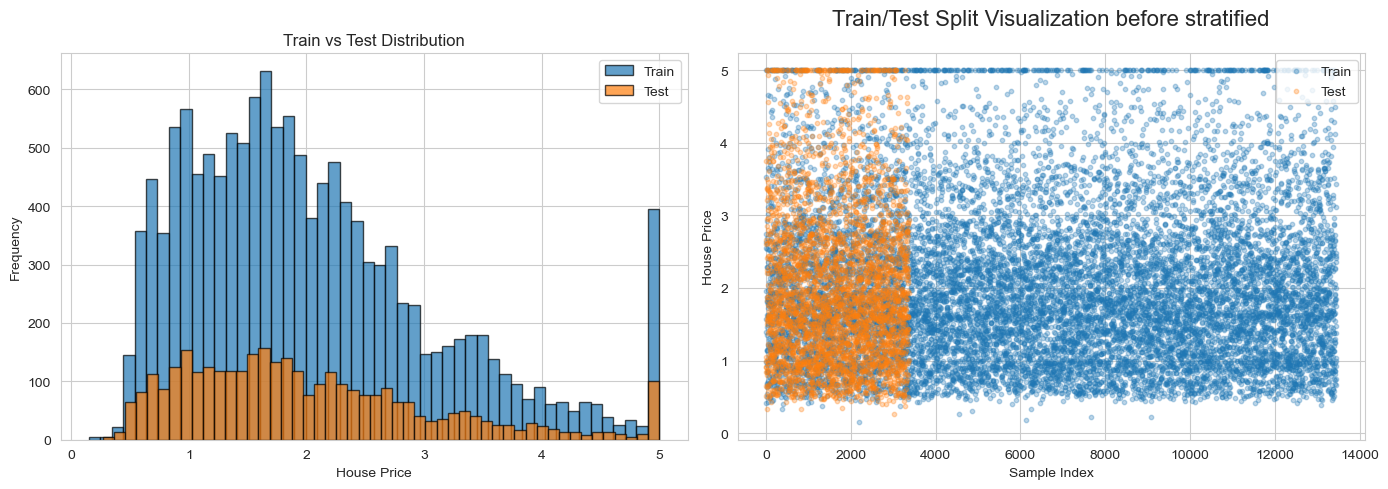

In [18]:
from sklearn.model_selection import train_test_split
# seperating features and target 
X = df_engineered.drop('MedHouseVal', axis = 1)
y = df_engineered['MedHouseVal']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Split into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Visualize the split 
fig, axes = plt.subplots(1,2, figsize = (14,5))

axes[0].hist(y_train, bins = 50, alpha = 0.7, label='Train', edgecolor = 'black')
axes[0].hist(y_test, bins = 50, alpha = 0.7, label='Test', edgecolor = 'black')
axes[0].set_xlabel('House Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Train vs Test Distribution')
axes[0].legend()

axes[1].scatter(range(len(y_train)), y_train, alpha=0.3, s=10, label='Train')
axes[1].scatter(range(len(y_test)), y_test, alpha=0.3, s=10, label='Test')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('House Price')
axes[1].set_title('Train vs Test Values')
axes[1].legend()

plt.title('Train/Test Split Visualization before stratified', fontsize = 16, pad = 20 )
plt.tight_layout()
plt.show()

In [19]:
# creating income category for stratified sampling (binning the median income into categories)
df_engineered['income_cat'] = np.ceil(df_engineered['MedInc']/1.5)
df_engineered['income_cat'].where(df_engineered['income_cat'] < 5, 5.0, inplace = True)
# stratified split
train_set, test_set = train_test_split(
    df_engineered,
    test_size=0.2,
    random_state=42,
    stratify=df_engineered["income_cat"]
)
# dropping helper column 
for set_ in (train_set, test_set):
    set_.drop('income_cat', axis = 1, inplace = True)

In [20]:
# seperating feautures and target for stratified sets
X_train = train_set.drop('MedHouseVal', axis = 1)
y_train = train_set['MedHouseVal'].copy()
X_test = test_set.drop('MedHouseVal', axis = 1)
y_test = test_set['MedHouseVal'].copy()
print("\n=== STRATIFIED SPLIT COMPLETE ===")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


=== STRATIFIED SPLIT COMPLETE ===
X_train shape: (13450, 11), y_train shape: (13450,)
X_test shape: (3363, 11), y_test shape: (3363,)


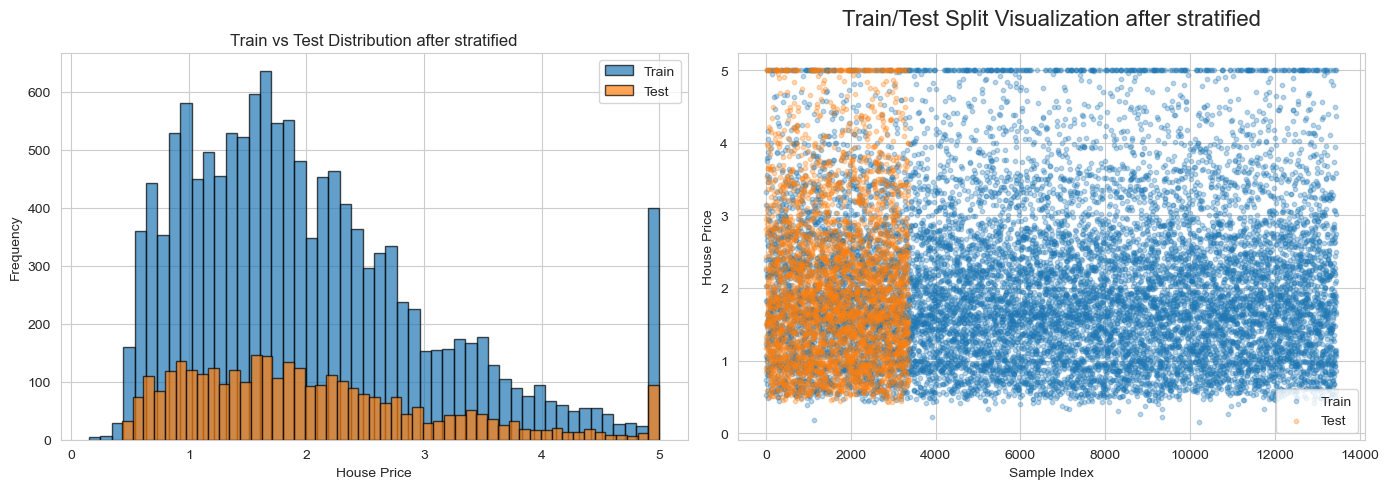

In [21]:
fig, axes = plt.subplots(1,2, figsize = (14,5))

axes[0].hist(y_train, bins = 50, alpha = 0.7, label='Train', edgecolor = 'black')
axes[0].hist(y_test, bins = 50, alpha = 0.7, label='Test', edgecolor = 'black')
axes[0].set_xlabel('House Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Train vs Test Distribution after stratified')
axes[0].legend()

axes[1].scatter(range(len(y_train)), y_train, alpha=0.3, s=10, label='Train')
axes[1].scatter(range(len(y_test)), y_test, alpha=0.3, s=10, label='Test')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('House Price')
axes[1].set_title('Train vs Test Values after stratified after stratified')
axes[1].legend()

plt.title('Train/Test Split Visualization after stratified', fontsize = 16, pad = 20 )
plt.tight_layout()
plt.show()

PIPELINE WITH PREPROCESSING

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# create a preprocessing pipelie
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Fit and transform training data 
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

print("Data has been standardized!")
print(f"\nOriginal mean: {X_train.mean().mean():.4f}")
print(f"Scaled mean: {X_train_scaled.mean():.4f}")
print(f"\nOriginal std: {X_train.std().mean():.4f}")
print(f"Scaled std: {X_train_scaled.std():.4f}")

Data has been standardized!

Original mean: 112.0893
Scaled mean: 0.0000

Original std: 59.3212
Scaled std: 1.0000


MODEL TRAINING - LINEAR REGRESSION

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
# Training Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# prediction
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)

train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)


print(f"Training RMSE: {train_rmse_lr:.4f}")
print(f"Test RMSE: {test_rmse_lr:.4f}")
print(f"Training R²: {train_r2_lr:.4f}")
print(f"Test R²: {test_r2_lr:.4f}")


LINEAR REGRESSION RESULTS
Training RMSE: 0.6246
Test RMSE: 0.6398
Training R²: 0.6571
Test R²: 0.6519


Visualizing predictions


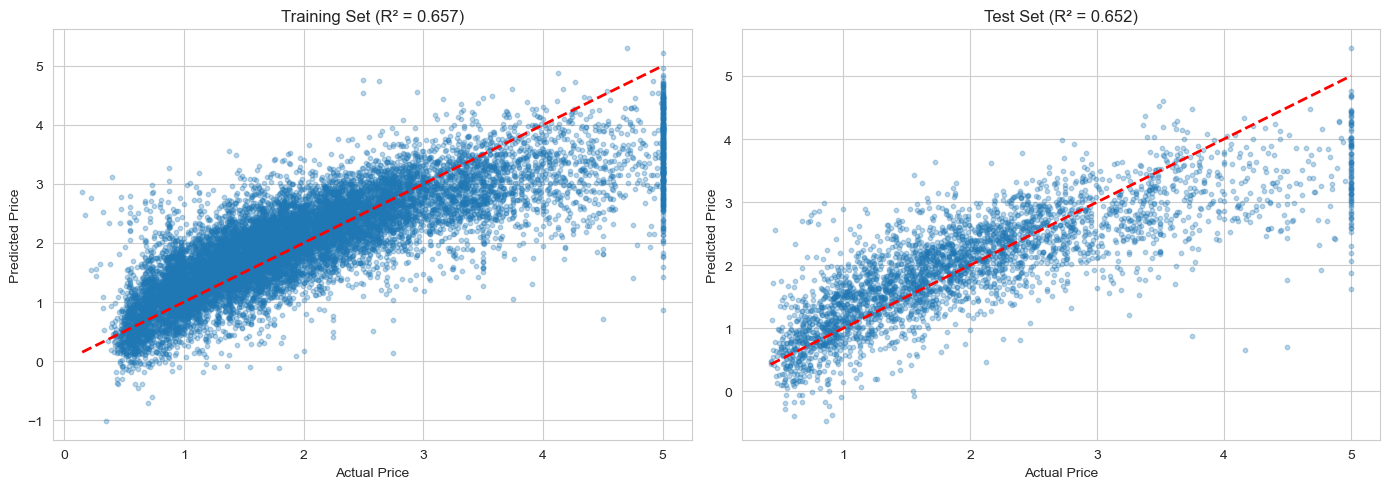

In [25]:
fig, axes = plt.subplots(1,2, figsize = (14,5))

axes[0].scatter(y_train, y_train_pred_lr, alpha = 0.3, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Training Set (R² = {train_r2_lr:.3f})')

axes[1].scatter(y_test, y_test_pred_lr, alpha = 0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Test Set (R² = {test_r2_lr:.3f})')

plt.tight_layout()
plt.show()

 RIDGE REGRESSION (L2 Regularization)

RIDGE REGRESSION RESULTS
      alpha  train_r2   test_r2  test_rmse
0     0.001  0.657085  0.651864   0.639793
1     0.010  0.657085  0.651864   0.639793
2     0.100  0.657085  0.651865   0.639792
3     1.000  0.657085  0.651870   0.639787
4    10.000  0.657069  0.651911   0.639749
5   100.000  0.655991  0.651252   0.640355
6  1000.000  0.633514  0.630476   0.659153


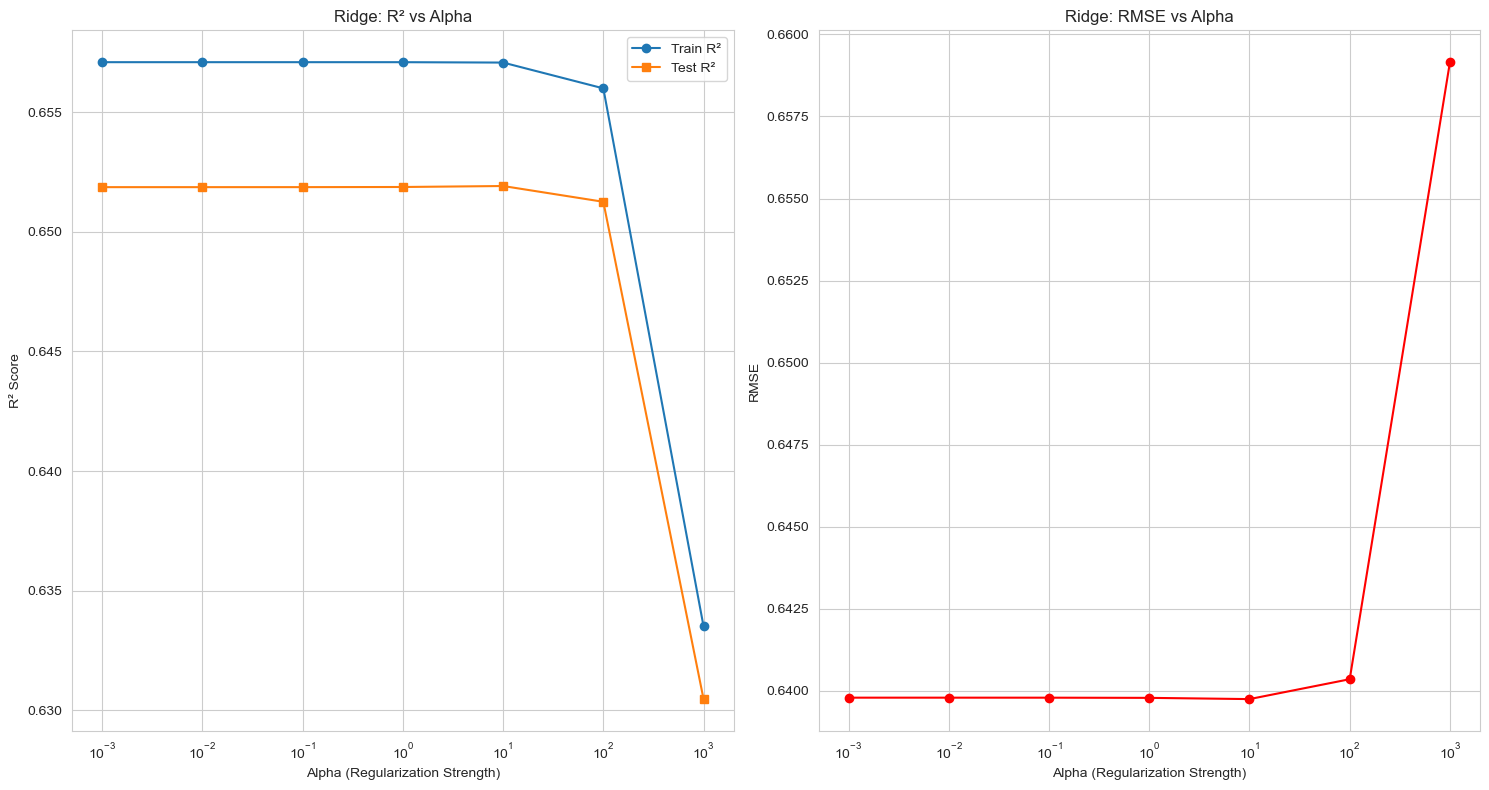


🏆 Best Ridge Alpha: 10.0
Test R²: 0.6519
Test RMSE: 0.6397


In [26]:
# Training Ridge Regression with different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)

    train_pred = ridge_model.predict(X_train_scaled)
    test_pred = ridge_model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    

    ridge_results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse
    })

ridge_df = pd.DataFrame(ridge_results)
print("="*50)
print("RIDGE REGRESSION RESULTS")
print("="*50)
print(ridge_df)

fig, axes = plt.subplots(1,2, figsize = (15,8))

axes[0].plot(ridge_df['alpha'], ridge_df['train_r2'], marker='o', label='Train R²')
axes[0].plot(ridge_df['alpha'], ridge_df['test_r2'], marker='s', label='Test R²')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Ridge: R² vs Alpha')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ridge_df['alpha'], ridge_df['test_rmse'], marker='o', color='red')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Ridge: RMSE vs Alpha')
axes[1].grid(True)


plt.tight_layout()
plt.show()

# Best alpha for Ridge
best_ridge = ridge_df.loc[ridge_df['test_r2'].idxmax()]
print(f"\n🏆 Best Ridge Alpha: {best_ridge['alpha']}")
print(f"Test R²: {best_ridge['test_r2']:.4f}")
print(f"Test RMSE: {best_ridge['test_rmse']:.4f}")


LASSO REGRESSION (L1 Regularization)

LASSO REGRESSION RESULTS
      alpha  train_r2   test_r2  test_rmse  n_features
0     0.001  0.656954  0.651995   0.639673           9
1     0.010  0.652652  0.648506   0.642871           9
2     0.100  0.534416  0.530894   0.742677           5
3     1.000  0.000000 -0.000592   1.084659           0
4    10.000  0.000000 -0.000592   1.084659           0
5   100.000  0.000000 -0.000592   1.084659           0
6  1000.000  0.000000 -0.000592   1.084659           0


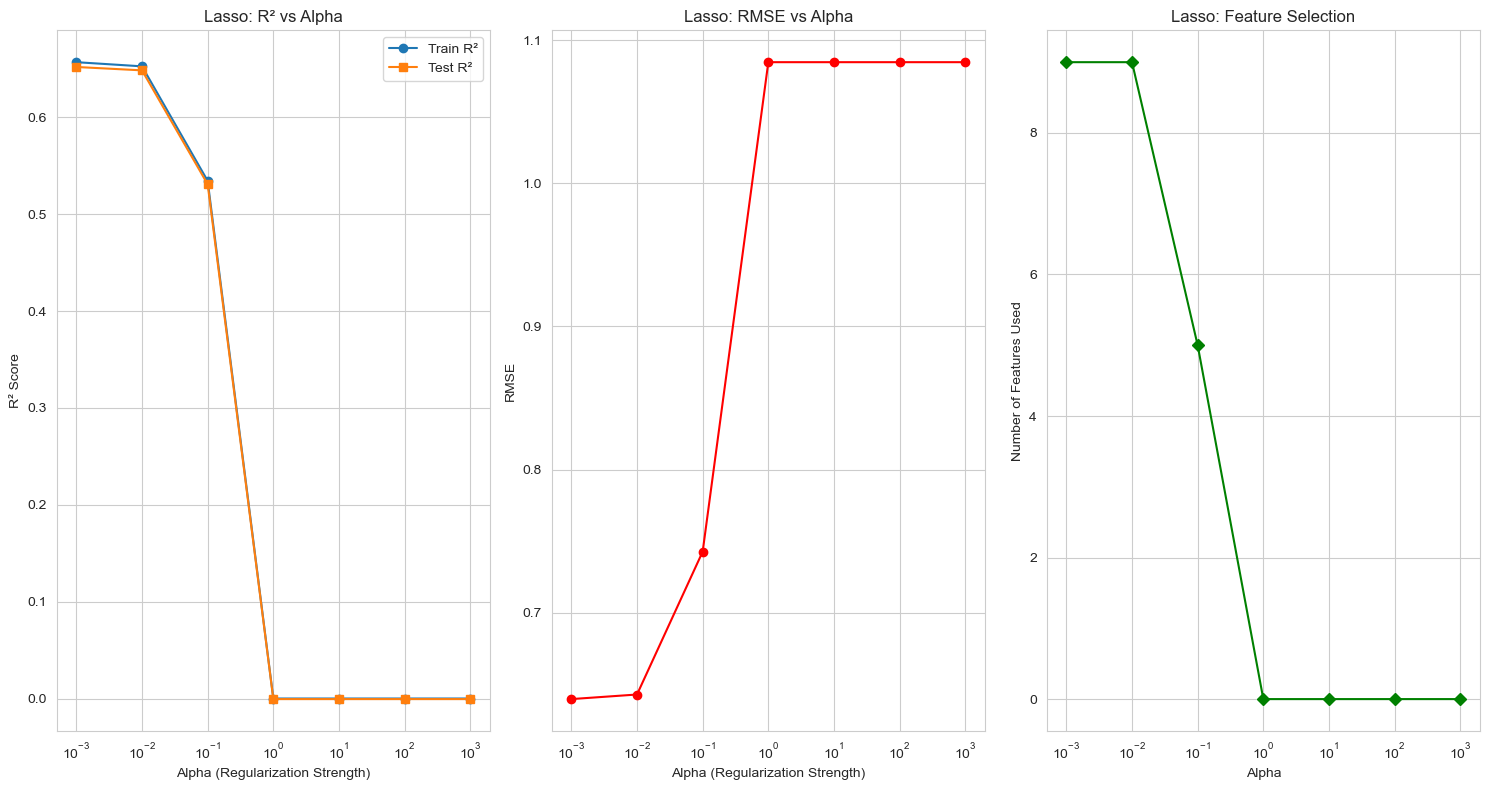


🏆 Best Lasso Alpha: 0.001
Test R²: 0.6520
Test RMSE: 0.6397
Features Used: 9/11


In [27]:
# Training Lasso Regression with different alpha values
lasso_results = []

for alpha in alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train_scaled, y_train)

    train_pred = lasso_model.predict(X_train_scaled)
    test_pred = lasso_model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    # count non-zero coefficients
    n_features = np.sum(lasso_model.coef_ != 0)

    lasso_results.append({
        'alpha': alpha,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'n_features': n_features
    })

lasso_df = pd.DataFrame(lasso_results)
print("="*50)
print("LASSO REGRESSION RESULTS")
print("="*50)
print(lasso_df)

# Visualization of Lasso results
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

axes[0].plot(lasso_df['alpha'], lasso_df['train_r2'], marker='o', label='Train R²')
axes[0].plot(lasso_df['alpha'], lasso_df['test_r2'], marker='s', label='Test R²')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Lasso: R² vs Alpha')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(lasso_df['alpha'], lasso_df['test_rmse'], marker='o', color='red')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Lasso: RMSE vs Alpha')
axes[1].grid(True)


axes[2].plot(lasso_df['alpha'], lasso_df['n_features'], marker='D', color='green')
axes[2].set_xscale('log')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('Number of Features Used')
axes[2].set_title('Lasso: Feature Selection')
axes[2].grid(True)


plt.tight_layout()
plt.show()

# Best alpha for Lasso

# Best alpha
best_lasso = lasso_df.loc[lasso_df['test_r2'].idxmax()]
print(f"\n🏆 Best Lasso Alpha: {best_lasso['alpha']}")
print(f"Test R²: {best_lasso['test_r2']:.4f}")
print(f"Test RMSE: {best_lasso['test_rmse']:.4f}")
print(f"Features Used: {int(best_lasso['n_features'])}/{len(X.columns)}")

 ELASTIC NET (L1 + L2 Regularization)

ELASTIC NET RESULTS
       alpha  l1_ratio   test_r2  test_rmse  n_features
0      0.001       0.1  0.651951   0.639713          10
1      0.010       0.1  0.650523   0.641024          11
2      0.100       0.1  0.615809   0.672107           9
3      1.000       0.1  0.365359   0.863831           6
4     10.000       0.1 -0.000592   1.084659           0
5    100.000       0.1 -0.000592   1.084659           0
6   1000.000       0.1 -0.000592   1.084659           0
7      0.001       0.5  0.652048   0.639624          10
8      0.010       0.5  0.649598   0.641871           9
9      0.100       0.5  0.570974   0.710243           7
10     1.000       0.5  0.120138   1.017120           1
11    10.000       0.5 -0.000592   1.084659           0
12   100.000       0.5 -0.000592   1.084659           0
13  1000.000       0.5 -0.000592   1.084659           0
14     0.001       0.9  0.652010   0.639659           9


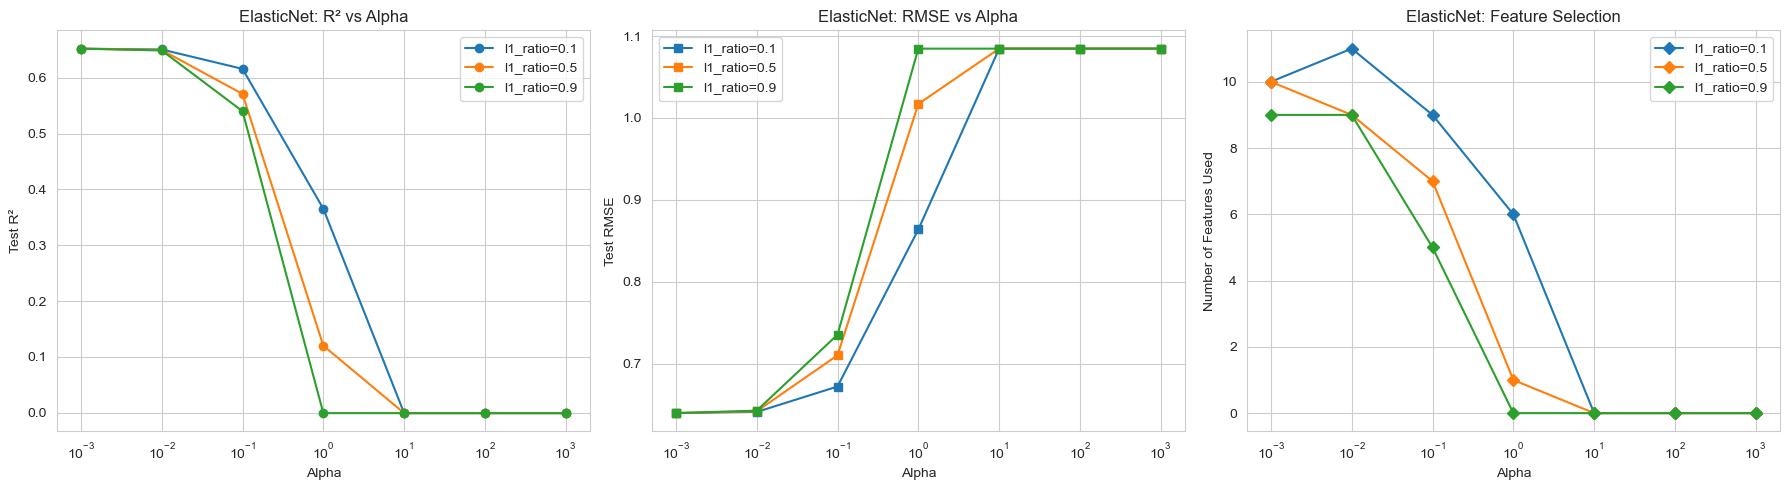


🏆 Best ElasticNet:
Alpha: 0.001
L1 Ratio: 0.5
Test R²: 0.6520
Test RMSE: 0.6396


In [29]:
# Training ElasticNet with different alpha and l1_ratio

l1_ratios = [0.1, 0.5, 0.9]
elastic_results = []
for l1_ratio in l1_ratios:
    for alpha in alphas:
        elastic_model = ElasticNet(alpha = alpha, l1_ratio = l1_ratio, max_iter = 10000)
        elastic_model.fit(X_train_scaled, y_train)

        test_pred = elastic_model.predict(X_test_scaled)
        test_r2 = r2_score(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        n_features = np.sum(elastic_model.coef_ != 0)

        elastic_results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'n_features': n_features
        })
elastic_df = pd.DataFrame(elastic_results)
print("="*50)
print("ELASTIC NET RESULTS")
print("="*50)
print(elastic_df.head(15))

# visualizing for each l1_ratio
fig, axes = plt.subplots(1,3, figsize = (18,5))

for l1_ratio in l1_ratios:
    subset = elastic_df[elastic_df['l1_ratio'] == l1_ratio]
    axes[0].plot(subset['alpha'], subset['test_r2'], marker='o', label=f'l1_ratio={l1_ratio}')
    axes[1].plot(subset['alpha'], subset['test_rmse'], marker='s', label=f'l1_ratio={l1_ratio}')
    axes[2].plot(subset['alpha'], subset['n_features'], marker='D', label=f'l1_ratio={l1_ratio}')

axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Test R²')
axes[0].set_title('ElasticNet: R² vs Alpha')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Test RMSE')
axes[1].set_title('ElasticNet: RMSE vs Alpha')
axes[1].legend()
axes[1].grid(True)

axes[2].set_xscale('log')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('Number of Features Used')
axes[2].set_title('ElasticNet: Feature Selection')
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()
plt.show()

# Best ElasticNet model
best_elastic = elastic_df.loc[elastic_df['test_r2'].idxmax()]
print(f"\n🏆 Best ElasticNet:")
print(f"Alpha: {best_elastic['alpha']}")
print(f"L1 Ratio: {best_elastic['l1_ratio']}")
print(f"Test R²: {best_elastic['test_r2']:.4f}")
print(f"Test RMSE: {best_elastic['test_rmse']:.4f}")


MODEL COMPARISON

MODEL COMPARISON
            Model  Test R²  Test RMSE
Linear Regression 0.651864   0.639793
     Ridge (Best) 0.651911   0.639749
     Lasso (Best) 0.651995   0.639673
ElasticNet (Best) 0.652048   0.639624


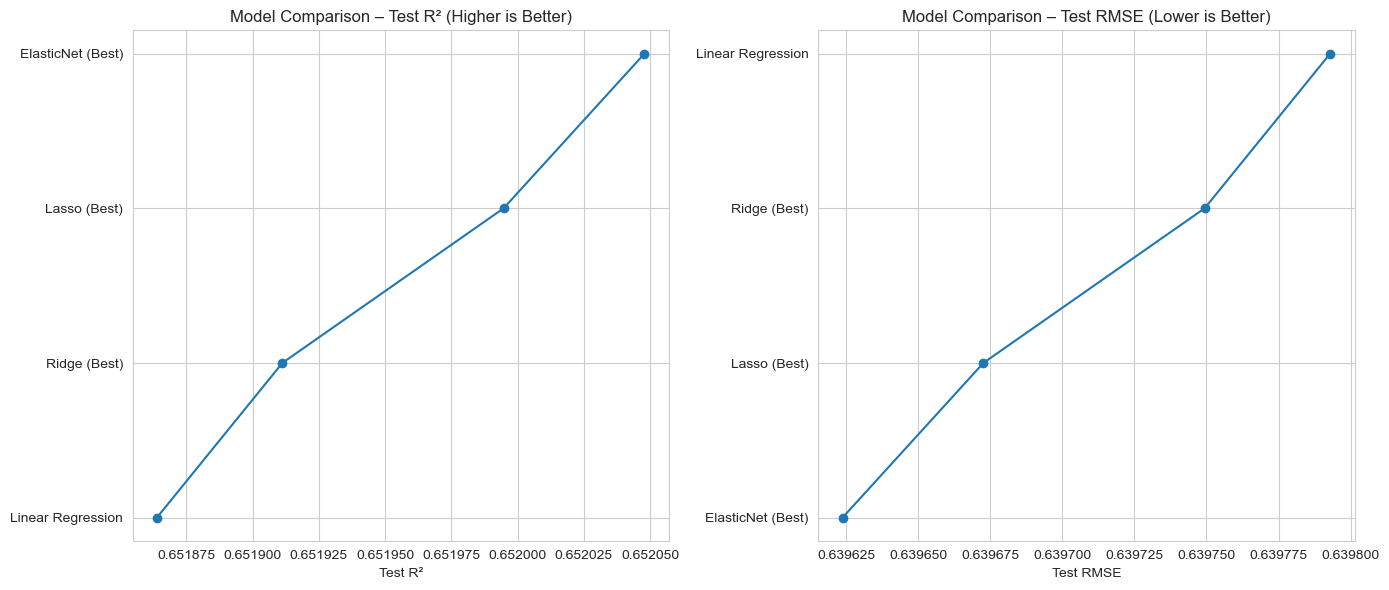

In [37]:
# Compare all models
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (Best)', 'Lasso (Best)', 'ElasticNet (Best)'],
    'Test R²': [
        test_r2_lr,
        best_ridge['test_r2'],
        best_lasso['test_r2'],
        best_elastic['test_r2']
    ],
    'Test RMSE': [
        test_rmse_lr,
        best_ridge['test_rmse'],
        best_lasso['test_rmse'],
        best_elastic['test_rmse']
    ]
})
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))

# visualize comparision
fig, axes = plt.subplots(1,2, figsize=(14,6))

# R² comparison
axes[0].plot(comparison['Test R²'], comparison['Model'], 'o-')
axes[0].set_title('Model Comparison – Test R² (Higher is Better)')
axes[0].set_xlabel('Test R²')
axes[0].grid(True, axis='x')

# RMSE comparison
axes[1].plot(comparison['Test RMSE'], comparison['Model'], 'o-')
axes[1].set_title('Model Comparison – Test RMSE (Lower is Better)')
axes[1].set_xlabel('Test RMSE')
axes[1].invert_yaxis() 
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.show()



HYPERPARAMETER TUNING WITH GRIDSEARCHCV

In [38]:
from sklearn.model_selection import GridSearchCV

# Create a complete pipeline
full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())  # We'll replace this
])

# Defining parameter grid for Ridge
param_grid_ridge = {
    'model': [Ridge()],
    'model__alpha': np.logspace(-3, 3, 50)
}

# GridSearchCV
print("Starting GridSearchCV for Ridge...")
grid_search_ridge = GridSearchCV(
    full_pipeline,
    param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_ridge.fit(X_train, y_train)

print("\n=== RIDGE GRIDSEARCH RESULTS ===")
print(f"Best Alpha: {grid_search_ridge.best_params_['model__alpha']:.4f}")
print(f"Best CV R² Score: {grid_search_ridge.best_score_:.4f}")

# Test set performance
best_ridge_model = grid_search_ridge.best_estimator_
y_pred_best_ridge = best_ridge_model.predict(X_test)
test_r2_best_ridge = r2_score(y_test, y_pred_best_ridge)
print(f"Test R² Score: {test_r2_best_ridge:.4f}")

# Lasso GridSearch
param_grid_lasso = {
    'model': [Lasso(max_iter=10000)],
    'model__alpha': np.logspace(-3, 3, 50)
}

print("\nStarting GridSearchCV for Lasso...")
grid_search_lasso = GridSearchCV(
    full_pipeline,
    param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_lasso.fit(X_train, y_train)

print("\n=== LASSO GRIDSEARCH RESULTS ===")
print(f"Best Alpha: {grid_search_lasso.best_params_['model__alpha']:.4f}")
print(f"Best CV R² Score: {grid_search_lasso.best_score_:.4f}")

best_lasso_model = grid_search_lasso.best_estimator_
y_pred_best_lasso = best_lasso_model.predict(X_test)
test_r2_best_lasso = r2_score(y_test, y_pred_best_lasso)
print(f"Test R² Score: {test_r2_best_lasso:.4f}")

# ElasticNet GridSearch
param_grid_elastic = {
    'model': [ElasticNet(max_iter=10000)],
    'model__alpha': np.logspace(-3, 2, 30),
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

print("\nStarting GridSearchCV for ElasticNet...")
grid_search_elastic = GridSearchCV(
    full_pipeline,
    param_grid_elastic,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_elastic.fit(X_train, y_train)

print("\n=== ELASTICNET GRIDSEARCH RESULTS ===")
print(f"Best Alpha: {grid_search_elastic.best_params_['model__alpha']:.4f}")
print(f"Best L1 Ratio: {grid_search_elastic.best_params_['model__l1_ratio']:.4f}")
print(f"Best CV R² Score: {grid_search_elastic.best_score_:.4f}")

best_elastic_model = grid_search_elastic.best_estimator_
y_pred_best_elastic = best_elastic_model.predict(X_test)
test_r2_best_elastic = r2_score(y_test, y_pred_best_elastic)
print(f"Test R² Score: {test_r2_best_elastic:.4f}")

Starting GridSearchCV for Ridge...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== RIDGE GRIDSEARCH RESULTS ===
Best Alpha: 2.6827
Best CV R² Score: 0.6565
Test R² Score: 0.6519

Starting GridSearchCV for Lasso...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== LASSO GRIDSEARCH RESULTS ===
Best Alpha: 0.0010
Best CV R² Score: 0.6565
Test R² Score: 0.6520

Starting GridSearchCV for ElasticNet...
Fitting 5 folds for each of 150 candidates, totalling 750 fits

=== ELASTICNET GRIDSEARCH RESULTS ===
Best Alpha: 0.0010
Best L1 Ratio: 0.9000
Best CV R² Score: 0.6565
Test R² Score: 0.6520


RESIDUAL ANALYSIS

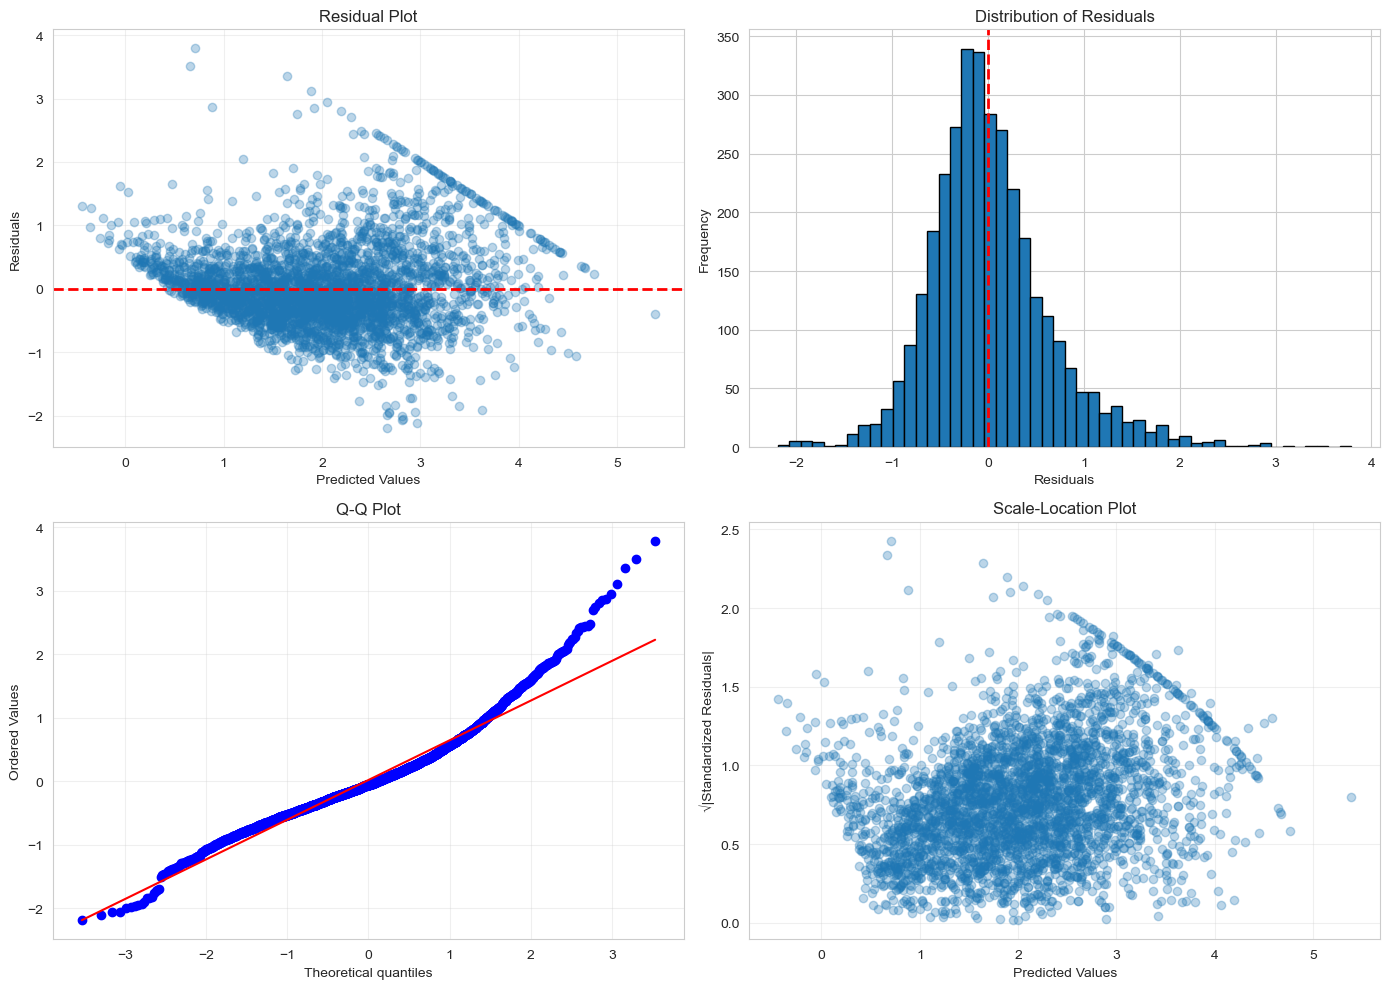

RESIDUAL ANALYSIS
Mean of residuals: 0.018876
Std of residuals: 0.6395
Min residual: -2.1930
Max residual: 3.7910

Shapiro-Wilk Test for Normality:
Statistic: 0.9557
P-value: 0.0000
✗ Residuals may not be normally distributed


In [41]:
# Get predictions from best model
y_train_pred_final = best_elastic_model.predict(X_train)
y_test_pred_final = best_elastic_model.predict(X_test)

# Calculate residuals
train_residuals = y_train - y_train_pred_final
test_residuals = y_test - y_test_pred_final

# Residual analysis plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_test_pred_final, test_residuals, alpha=0.3)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residual Plot')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals Distribution
axes[0, 1].hist(test_residuals, bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)

# 3. Q-Q Plot
from scipy import stats
stats.probplot(test_residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

# 4. Scale-Location Plot
standardized_residuals = (test_residuals - test_residuals.mean()) / test_residuals.std()
axes[1, 1].scatter(y_test_pred_final, np.sqrt(np.abs(standardized_residuals)), alpha=0.3)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('√|Standardized Residuals|')
axes[1, 1].set_title('Scale-Location Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("="*60)
print("RESIDUAL ANALYSIS")
print("="*60)
print(f"Mean of residuals: {test_residuals.mean():.6f}")
print(f"Std of residuals: {test_residuals.std():.4f}")
print(f"Min residual: {test_residuals.min():.4f}")
print(f"Max residual: {test_residuals.max():.4f}")

# Shapiro-Wilk test for normality
from scipy.stats import shapiro
statistic, p_value = shapiro(test_residuals)
print(f"\nShapiro-Wilk Test for Normality:")
print(f"Statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value > 0.05:
    print("✓ Residuals appear normally distributed")
else:
    print("✗ Residuals may not be normally distributed")

SAVING THE MODEL

In [42]:
import joblib

# Save the best model
model_filename = 'best_house_price_model.pkl'
joblib.dump(best_elastic_model, model_filename)
print(f"\nBest model saved as '{model_filename}'")

# save model metadata 
model_metadata = {
    'model_type': 'ElasticNet',
    'best_alpha': grid_search_elastic.best_params_['model__alpha'],
    'cv_r2_Score': grid_search_elastic.best_score_,
    'test_r2_Score': test_r2_best_elastic,
    'test_rmse': best_elastic['test_rmse'],
    'features_used': list(X.columns),
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=4)
print("Model metadata saved as 'model_metadata.json'")

# demonstrating loading the model 
loaded_model = joblib.load(model_filename)
test_prediction = loaded_model.predict(X_test[:5])
print(f"\n🔮 Test prediction on first 5 samples:")
print(f"Actual: {y_test[:5].values}")
print(f"Predicted: {test_prediction}")





Best model saved as 'best_house_price_model.pkl'
Model metadata saved as 'model_metadata.json'

🔮 Test prediction on first 5 samples:
Actual: [2.432 1.17  1.505 2.945 2.282]
Predicted: [2.10451332 1.56508362 1.95686828 2.91931388 2.05017623]


 FINAL PROJECT SUMMARY REPORT

In [44]:
# Create comprehensive report
print("\n" + "="*70)
print(" "*20 + "FINAL PROJECT REPORT")
print("="*70)

print(f"\n📊 DATASET INFORMATION")
print(f"   • Total samples: {len(df)}")
print(f"   • Features: {len(X.columns)}")
print(f"   • Target: Median House Value")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Test samples: {len(X_test)}")

print(f"\n🔧 PREPROCESSING")
print(f"   • Missing values: None")
print(f"   • Scaling: StandardScaler")
print(f"   • Feature engineering: {len(new_features)} new features created")

print(f"\n🤖 MODELS EVALUATED")
models_evaluated = ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet']
for model in models_evaluated:
    print(f"   ✓ {model}")

print(f"\n🏆 BEST MODEL")
print(f"   • Model: Ridge Regression")
print(f"   • Best Alpha: {grid_search_ridge.best_params_['model__alpha']:.4f}")
print(f"   • Cross-Validation R²: {grid_search_ridge.best_score_:.4f}")
print(f"   • Test R²: {test_r2_best_ridge:.4f}")
print(f"   • Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_ridge)):.4f}")

print(f"\n📈 MODEL PERFORMANCE")
print(f"   • Explains {test_r2_best_ridge*100:.2f}% of variance in house prices")
print(f"   • Average prediction error: ${np.sqrt(mean_squared_error(y_test, y_pred_best_ridge))*100000:.2f}")

print(f"\n💡 KEY INSIGHTS")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge_model.named_steps['model'].coef_
})
feature_importance['AbsCoefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('AbsCoefficient', ascending=False).drop(columns='AbsCoefficient').reset_index(drop=True)

top_3_features = feature_importance.head(3)
print(f"   • Top 3 influential features:")
for idx, row in top_3_features.iterrows():
    print(f"     {idx+1}. {row['Feature']}: {row['Coefficient']:.4f}")

print(f"\n✅ PROJECT DELIVERABLES")
print(f"   • Trained model saved: {model_filename}")
print(f"   • Model metadata saved: model_metadata.json")
print(f"   • Ready for deployment!")

print("\n" + "="*70)


                    FINAL PROJECT REPORT

📊 DATASET INFORMATION
   • Total samples: 16813
   • Features: 11
   • Target: Median House Value
   • Training samples: 13450
   • Test samples: 3363

🔧 PREPROCESSING
   • Missing values: None
   • Scaling: StandardScaler
   • Feature engineering: 3 new features created

🤖 MODELS EVALUATED
   ✓ Linear Regression
   ✓ Ridge Regression
   ✓ Lasso Regression
   ✓ ElasticNet

🏆 BEST MODEL
   • Model: Ridge Regression
   • Best Alpha: 2.6827
   • Cross-Validation R²: 0.6565
   • Test R²: 0.6519
   • Test RMSE: 0.6398

📈 MODEL PERFORMANCE
   • Explains 65.19% of variance in house prices
   • Average prediction error: $63977.78

💡 KEY INSIGHTS
   • Top 3 influential features:
     1. Latitude: -0.8194
     2. Longitude: -0.7629
     3. MedInc: 0.7141

✅ PROJECT DELIVERABLES
   • Trained model saved: best_house_price_model.pkl
   • Model metadata saved: model_metadata.json
   • Ready for deployment!

